# 03 - Training

This notebook validates the training pipeline before spending GPU time on the full sweep, then runs it.

Three things happen, in this order and no other: prove the training pipeline runs end to end
on a tiny model, measure the "before" number on a model that has not been trained, and only
then run the `r` sweep. Anything findable in ten minutes on a 0.6B model must not be found
after an hour of training a 1.7B one.

This notebook only reads from `data/processed/`. It does not clean and it does not re-split -
otherwise every run would train on slightly different data and the runs could not be compared.
It never touches `clean/test`: this stage selects a configuration out of three, and a number used
to select is no longer a neutral estimate of anything.

## 0 - Bootstrap, GPU, and the three blocking checks


### Getting the repository onto the runtime

**The runtime cannot see this file's folder.** The VS Code Colab extension runs these cells on
a Colab VM and syncs no files in either direction — the editor is local, the kernel is not.
So `src/`, `artifacts/` and `results/metrics/baselines_summary.csv` have to arrive some other
way, and the way is a clone from GitHub.

The consequence is worth stating plainly, because it is silent and it is expensive: **on a
Colab runtime this notebook runs the code that is pushed, not the code that is open in the
editor.** An edit to `src/train.py` that has not been committed and pushed does not exist as
far as the sweep below is concerned, and nothing raises — the runs simply describe the previous
version. So the cell below prints the commit it is running, and the habit that goes with it is
to commit and push *before* connecting, every time.

Run locally or in the Colab web UI, the cell finds the repo already on disk and clones nothing.


In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/Emma-V/support-triage.git"
BRANCH   = "main"
CLONE_TO = Path("/content/support-triage")


def _git(*args, cwd=None) -> str:
    return subprocess.run(["git", *args], cwd=cwd, check=True,
                          capture_output=True, text=True).stdout.strip()


def _find_repo(start: Path):
    """Walk up from `start` looking for the marker file that identifies the repo."""
    here = start.resolve()
    while not (here / "src" / "data.py").exists():
        if here == here.parent:
            return None
        here = here.parent
    return here


REPO_ROOT = _find_repo(Path.cwd())

# The second condition is the one that took a while to find. Running this cell
# a second time starts from a working directory the FIRST run chdir'd into, so
# _find_repo succeeds - and a plain `if REPO_ROOT is None` then skips the update
# and silently keeps whatever commit the runtime happened to start with. The
# clone must be refreshed whenever it is the thing we are standing in.
if REPO_ROOT is None or REPO_ROOT == CLONE_TO:
    # A Colab runtime, so the repo comes from GitHub. CLONE_TO is on the runtime's
    # own disk and is disposable, which is what makes the hard reset safe - a local
    # checkout is never equal to CLONE_TO, so it can never be reached from here.
    if (CLONE_TO / ".git").exists():
        _git("fetch", "origin", BRANCH, cwd=CLONE_TO)
        _git("reset", "--hard", f"origin/{BRANCH}", cwd=CLONE_TO)
        print(f"updated the existing clone at {CLONE_TO}")
    else:
        _git("clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(CLONE_TO))
        print(f"cloned {REPO_URL} to {CLONE_TO}")
    REPO_ROOT = CLONE_TO

os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

print(f"\nrepo   {REPO_ROOT}")
print(f"commit {_git('rev-parse', '--short', 'HEAD', cwd=REPO_ROOT)}  "
      f"{_git('log', '-1', '--pretty=%s', cwd=REPO_ROOT)}")
print("\n^ THIS is the code that will run, and on Colab it comes from GitHub rather")
print("  than from the editor. If it is not the commit you last pushed, every number")
print("  below describes a different src/train.py than the one open in VS Code.")


cloned https://github.com/Emma-V/support-triage.git to /content/support-triage

repo   /content/support-triage
commit a2d5cc5  Remove the KV-cache fast path from label scoring

^ THIS is the code that will run, and on Colab it comes from GitHub rather
  than from the editor. If it is not the commit you last pushed, every number
  below describes a different src/train.py than the one open in VS Code.


In [2]:
# Two packages, and they move together. peft reaches into transformers internals,
# so a peft older than the transformers beside it raises an ImportError from inside
# get_peft_model - a hundred lines below the line that is actually wrong, and after
# the model has already been downloaded. Asking whether peft is merely *present* is
# not enough of a check: Colab ships one, it is just not this one.
#
# A third package is handled here too, and it is handled by being removed. See below.
#
# torch stays unpinned on purpose. It is linked against the runtime's CUDA build and
# installing a pinned torch on top of that is the most reliable way to break a Colab
# GPU, which is why requirements.txt leaves this half of the project unpinned.
import importlib
import importlib.metadata as metadata
import subprocess
import sys

PINNED = {"transformers": "5.14.1", "peft": "0.20.0"}   # the pair in requirements.txt
TORCHAO_MIN_FOR_PEFT = (0, 16)                          # peft's TORCHAO_MINIMUM_VERSION

# torchao is the third package, and the fix for it is uninstallation. Colab preinstalls
# 0.10; peft 0.20 accepts nothing below 0.16, and it does not decline quietly. Attaching
# a LoRA adapter asks every backend in turn whether it is available, and torchao answers
# that question by *raising* ImportError - so the failure surfaces from inside
# get_peft_model, fifteen frames deep in peft, naming a quantisation library this
# project never uses, after the model has downloaded. Upgrading it is the wrong repair:
# torchao ships extensions compiled against one specific torch, so pulling a newer one
# reaches torch, which is the thing this cell exists to leave alone. Nothing here
# quantises, so the unused backend comes off the path instead of being modernised.
try:
    have_torchao = metadata.version("torchao")
except metadata.PackageNotFoundError:
    have_torchao = None

stale_torchao = have_torchao is not None and tuple(
    int("".join(c for c in chunk if c.isdigit()) or "0")
    for chunk in have_torchao.split(".")[:2]
) < TORCHAO_MIN_FOR_PEFT

print(f"{'torchao':14s} found {have_torchao or 'nothing':10s} "
      f"{'too old for peft - removing it' if stale_torchao else 'not in the way'}")
if stale_torchao:
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "torchao"],
                   check=True)
    importlib.invalidate_caches()   # so the next find_spec("torchao") sees the removal
    print(f"{'':14s} removed - no restart needed, peft only asks at adapter time")

replaced = []
for package, want in PINNED.items():
    try:
        have = metadata.version(package)
    except metadata.PackageNotFoundError:
        have = None
    print(f"{package:14s} found {have or 'nothing':10s} want {want}")
    if have != want:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        f"{package}=={want}"], check=True)
        replaced.append(f"{package} {have or 'missing'} -> {want}")

if replaced:
    print()
    print("!" * 70)
    print("REPLACED: " + "; ".join(replaced))
    loaded = [name for name in PINNED if name in sys.modules]
    if loaded:
        print(f"Python is already holding {', '.join(loaded)} in memory, and an import")
        print("cannot replace a module that is already loaded. RESTART THE KERNEL and")
        print("run this notebook from the top - everything above here is cheap.")
        print("!" * 70)
        raise RuntimeError("restart the kernel: a pinned package was replaced under it")
    print("!" * 70)

import peft
import torch
import transformers

print(f"torch {torch.__version__} | transformers {transformers.__version__} | peft {peft.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    print()
    print("!! No GPU on this runtime. In VS Code the runtime is chosen when you pick")
    print("   the kernel - reconnect and select a T4 runtime. Nothing below will work.")


torchao        found 0.10.0     too old for peft - removing it
               removed - no restart needed, peft only asks at adapter time
transformers   found 5.15.0     want 5.14.1
peft           found 0.20.0     want 0.20.0

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
REPLACED: transformers 5.15.0 -> 5.14.1
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
torch 2.11.0+cu128 | transformers 5.14.1 | peft 0.20.0
CUDA available: True


In [3]:
import importlib.util
import json, os, sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Colab is detected by the module, not by /content. On Windows a leading slash
# is drive-relative - Path("/content") is C:\content - so a local run that once
# fell back to /content/_local_runs creates the very directory that makes every
# later local run claim to be Colab, and then section 1 stops on a Drive that
# was never going to mount. google.colab is also what the mount below actually
# needs, so this asks the question whose answer is being used.
IN_COLAB = importlib.util.find_spec("google.colab") is not None

# Repo root, whether this runs locally or from a Colab clone. The bootstrap cell
# above has already chdir'd into it on a Colab runtime; the search is repeated so
# this cell still stands on its own when the repo is simply there.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src" / "data.py").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "src" / "data.py").exists(), (
    f"No repository found above {Path.cwd()}. Run the bootstrap cell above first - "
    "on a Colab runtime it is what puts the repo on the machine.")
sys.path.insert(0, str(REPO_ROOT))

from src import data as D
from src import evaluate as E
from src import train as T

METRICS_DIR = REPO_ROOT / "results" / "metrics"
ERRORS_DIR  = REPO_ROOT / "results" / "errors"
FIGURES_DIR = REPO_ROOT / "results" / "figures"
PROMPTS_DIR = REPO_ROOT / "results" / "prompts"
for d in (METRICS_DIR, ERRORS_DIR, FIGURES_DIR, PROMPTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("repo:", REPO_ROOT.name, "| colab:", IN_COLAB)
print("python", sys.version.split()[0], "| pandas", pd.__version__, "| numpy", np.__version__)

repo: support-triage | colab: True
python 3.13.15 | pandas 2.2.3 | numpy 2.1.3


### Where the adapters go, and where the data comes from

Two things Colab gets wrong by default, both of which cost a whole day when they bite.

**Adapters** are written to Drive, one directory per run. Colab's local disk is wiped when
the runtime dies, and a run whose output vanished has to be paid for twice. The repo gets the
JSON record only - an adapter is a training *output*, not code, and it does not go into git.

**The split files come with the clone.** All six CSVs and `full_corpus.csv` are committed -
6 MB in total, and it is what makes the project runnable by somebody who is not the author.
They are still not rebuilt here. `requirements.txt` pins the versions that produced the
committed hashes and Colab ships different ones; a rebuild that allocates one row differently
fails the manifest check, which is the assert working correctly and is still a lost hour.

**From VS Code there is a third thing.** `drive.mount` is a `google.colab` call, and those are
bridged into the extension one at a time — this one only since v0.2.1, and it is still the part
of the bridge that fails most. Everything below assumes the mount worked, so the cell checks
that `/content/drive/MyDrive` actually exists rather than trusting that `mount()` returned, and
says so loudly if it does not. An adapter written to an unmounted path is not saved anywhere.


In [4]:
# IN_COLAB, REPO_ROOT and the src imports all come from the cell above. Running
# this one on a fresh kernel is the easy mistake, and the NameError it raises
# names the wrong problem - so name the right one.
for _n in ("IN_COLAB", "REPO_ROOT"):
    if _n not in globals():
        raise RuntimeError(
            f"{_n} is not defined - run the imports-and-paths cell at the end of "
            "section 0 first (the one that prints: repo ... | colab ...). If that "
            "cell is the one that failed, fix it there: its error is the real one.")

# Set this to True ONLY to rehearse the notebook on a runtime where Drive cannot
# mount, accepting that everything the run produces dies with the machine. It is
# a variable rather than a comment so that "I meant to run without Drive" is a
# recorded choice in the notebook, instead of a warning somebody scrolled past.
ALLOW_NO_DRIVE = False

# drive.mount is the one call in this notebook that depends on the *editor* rather
# than on the runtime: it is supported from the VS Code extension only since v0.2.1
# and it is still the flakiest part of that bridge. So it is wrapped - an
# unmounted Drive has to be a named failure here, not a puzzling path error in
# section 4 after an hour of training has already been paid for.
DRIVE_OK = False
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DRIVE_OK = Path("/content/drive/MyDrive").exists()
    except Exception as exc:
        print(f"!! Drive did not mount - {type(exc).__name__}: {exc}")

# This used to print a banner and carry on, which is exactly how output from an
# entire session was previously lost: the banner printed, the notebook ran for
# two and a half hours writing into /content/_local_runs, and the runtime was
# closed on a machine holding every file it had produced. A warning at the top
# of a long run is not a control - nobody re-reads this cell's output an hour
# later. Stopping costs the thirty seconds it takes to remount; not stopping
# can cost a full session.
if IN_COLAB and not DRIVE_OK and not ALLOW_NO_DRIVE:
    raise RuntimeError(
        "Drive is not mounted, so nothing this notebook produces would survive the "
        "runtime. Fix it before the sweep:\n"
        "  - re-run this cell: the mount is flaky and often works the second time\n"
        "  - update the Colab VS Code extension (drive.mount needs v0.2.1+), or\n"
        "  - run this notebook in the Colab web UI instead.\n"
        "To rehearse without Drive anyway, set ALLOW_NO_DRIVE = True above and "
        "accept that every output below is disposable.")

if IN_COLAB and not DRIVE_OK:
    print("\n" + "!" * 70)
    print("RUNNING WITHOUT DRIVE, deliberately (ALLOW_NO_DRIVE = True). Adapters and")
    print("run records go to the runtime's own disk and are DELETED when it")
    print("disconnects. Nothing produced below is safe to report.")
    print("!" * 70)

DRIVE_ROOT = (Path("/content/drive/MyDrive/support-triage") if DRIVE_OK
              else Path("/content/_local_runs") if IN_COLAB
              else REPO_ROOT / "_local_runs")
RUNS_DIR = DRIVE_ROOT / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# The six split CSVs are committed, so a clone arrives with them. Missing files
# here mean a clone older than the commit that added them - a one-line fix, and
# not a data problem, so it should not read like one.
PROCESSED = REPO_ROOT / "data" / "processed"
if not (PROCESSED / "clean" / "train.csv").exists():
    raise FileNotFoundError(
        f"No split files in {PROCESSED}. They are in git, so this clone predates the "
        "commit that added them: re-run the bootstrap cell at the top of section 0 - "
        "it hard-resets the clone to origin/main and brings the data with it.")

print("runs go to:", RUNS_DIR)

Mounted at /content/drive
runs go to: /content/drive/MyDrive/support-triage/runs


### The fast pass, before the expensive one

`SMOKE = True` runs every cell below on a slice: one `r` instead of three, one epoch
instead of three, 512 training rows, and the "before" number measured on 128 validation
rows instead of all 2,120. It answers one question - *does this notebook run from top to
bottom without raising* - and it answers it in minutes instead of finding the answer two
hours in, on the last cell.

Nothing a smoke pass produces is a result, so nothing it produces is allowed near the real
ones: its tables, figures and adapters go to `results/**/_smoke/` and `runs/_smoke/`. A
figure with the right name in the right folder is indistinguishable from a real one three
days later, and that is a worse problem than a slow notebook. Set `SMOKE = False` and run
again for the numbers that go in the report.


In [5]:
SMOKE = False          # <- set to False for the real run

SWEEP_R      = (8,) if SMOKE else T.R_VALUES
SWEEP_EPOCHS = 1 if SMOKE else T.EPOCHS
SWEEP_ROWS   = 512 if SMOKE else None      # None means all of clean/train
SCORE_ROWS   = 128 if SMOKE else None      # rows behind the zero-shot number

# Recomputed from a base rather than reassigned, so that running this cell twice
# cannot produce runs/_smoke/_smoke.
RUNS_BASE   = RUNS_DIR.parent if RUNS_DIR.name == "_smoke" else RUNS_DIR
RUNS_DIR    = RUNS_BASE / "_smoke" if SMOKE else RUNS_BASE
OUT_METRICS = METRICS_DIR / "_smoke" if SMOKE else METRICS_DIR
OUT_ERRORS  = ERRORS_DIR / "_smoke" if SMOKE else ERRORS_DIR
OUT_FIGURES = FIGURES_DIR / "_smoke" if SMOKE else FIGURES_DIR
for d in (RUNS_DIR, OUT_METRICS, OUT_ERRORS, OUT_FIGURES):
    d.mkdir(parents=True, exist_ok=True)

if SMOKE:
    print("SMOKE PASS - a check that the notebook runs, not a result.")
    print(f"  r values    {SWEEP_R} instead of {T.R_VALUES}")
    print(f"  epochs      {SWEEP_EPOCHS} instead of {T.EPOCHS}")
    print(f"  train rows  {SWEEP_ROWS} instead of all of clean/train")
    print(f"  val rows    {SCORE_ROWS} for the before number, instead of all of clean/val")
    print(f"  writing to  {OUT_METRICS} and {RUNS_DIR}")
else:
    print("REAL RUN - three r values, three epochs, all of clean/train.")
    print(f"  writing to  {OUT_METRICS} and {RUNS_DIR}")



REAL RUN - three r values, three epochs, all of clean/train.
  writing to  /content/support-triage/results/metrics and /content/drive/MyDrive/support-triage/runs


### The three checks that block the first training cell

Each of these, when it fails, fails **silently** or with an error that points at the wrong
file. They are checked for exactly that reason, before a single training step runs.

| check | what fails if it is skipped |
|---|---|
| `transformers >= 4.51` | the loader raises a KeyError naming the *model*, which reads like a typo in the model id |
| GPU name and bf16 support | T4 has no bf16; two runs on different hardware are not comparable and the recorded runtimes become meaningless |
| padding token, agreed by model **and** tokenizer | a classification decoder pools the last non-pad token; disagreement makes it pool a pad position and score badly for no visible reason |

The fourth - that the classification head is saved with the adapter - cannot be tested by a
check at all. It needs a save, a load from scratch and a comparison, so it lives inside the
debug run.

In [6]:
import gc
import torch

VERSIONS = T.check_transformers_version()
print("transformers", VERSIONS["transformers"], ">=", VERSIONS["min_required"], "OK")

HARDWARE = T.gpu_report()
for k, v in HARDWARE.items():
    print(f"  {k:22s} {v}")

print("\nPRECISION DECIDED:", HARDWARE["precision"], "-", HARDWARE["precision_reason"])
print("^ copy this line and the GPU name into the run log. Runs on different hardware")
print("  are not comparable, and that is not recoverable after the runtime is gone.")

transformers 5.14.1 >= 4.51 OK
  gpu_name               NVIDIA L4
  compute_capability     8.9
  total_memory_gb        23.7
  bf16_supported         True
  device                 cuda
  precision              bf16
  precision_reason       bf16 supported by this GPU - preferred, no loss scaling needed

PRECISION DECIDED: bf16 - bf16 supported by this GPU - preferred, no loss scaling needed
^ copy this line and the GPU name into the run log. Runs on different hardware
  are not comparable, and that is not recoverable after the runtime is gone.


### The manifest check, before any number is produced

A check that runs *after* the results exist is decoration. If the split in this runtime is not
the split described in `split_manifest.json`, every number below describes a different dataset
than the report does.


In [7]:
manifest = json.loads((REPO_ROOT / "data" / "processed" / "split_manifest.json").read_text())
splits = D.load_all_splits(REPO_ROOT / "data" / "processed")
D.verify_against_manifest(manifest, splits)
print("manifest verified - all six split files match the frozen fingerprints\n")

clean_tr, clean_va = splits["clean"]["train"], splits["clean"]["val"]
INTENTS = json.loads((REPO_ROOT / "artifacts" / "labels.json").read_text())
assert len(INTENTS) == 27, len(INTENTS)

print(f"clean/train {len(clean_tr):,} rows   clean/val {len(clean_va):,} rows")
print(f"labels      {len(INTENTS)} intents, frozen order from artifacts/labels.json")
print(f"MAX_LENGTH  {D.MAX_LENGTH}  (measured in 01_data.ipynb: p99 = 19 tokens, max = 24)")

# The zero-shot cell scores this frame: all of clean/val, or a slice of it
# in a smoke pass. Training still validates on the whole of clean/val.
val_score = clean_va if SCORE_ROWS is None else clean_va.head(SCORE_ROWS)
if SCORE_ROWS is not None:
    print(f"SMOKE       the before number is measured on {len(val_score)} val rows")

# clean/test is loaded so the manifest check can hash all six files. Loading is not
# looking: nothing below reads it, and it is opened once, in 04_test.ipynb.
del splits["clean"]["test"], splits["naive"]["test"]

manifest verified - all six split files match the frozen fingerprints

clean/train 9,893 rows   clean/val 2,120 rows
labels      27 intents, frozen order from artifacts/labels.json
MAX_LENGTH  32  (measured in 01_data.ipynb: p99 = 19 tokens, max = 24)


### The baseline scores, as a scale

`0.9787` is not a target, it is a **fault detector**. A fine-tuned model that scores 0.3
is a broken pipeline and not a finding, because a linear model costing nothing reaches 0.9787
on exactly these rows. Without that number the only available reaction to a bad score would be
guessing.

In [8]:
baselines = pd.read_csv(METRICS_DIR / "baselines_summary.csv")
FLOOR    = float(baselines.query("run == 'majority_clean_intent'")["f1_macro"].iloc[0])
BASELINE = float(baselines.query("run == 'tfidf_clean'")["f1_macro"].iloc[0])
STRONGEST = float(baselines.query("run == 'tfidf_clean_charwb'")["f1_macro"].iloc[0])

print(f"floor  (majority class)          macro-F1 {FLOOR:.4f}")
print(f"headline baseline (word 1-2)     macro-F1 {BASELINE:.4f}")
print(f"strongest cheap model (char_wb)  macro-F1 {STRONGEST:.4f}")
print(f"\nheadroom above the headline baseline   {1 - BASELINE:.4f}")
print(f"headroom above the strongest one       {1 - STRONGEST:.4f}  <- the honest one")


floor  (majority class)          macro-F1 0.0041
headline baseline (word 1-2)     macro-F1 0.9787
strongest cheap model (char_wb)  macro-F1 0.9928

headroom above the headline baseline   0.0213
headroom above the strongest one       0.0072  <- the honest one


## 1 - The frozen hyper-parameters

This sweep is over `r` alone. That is only a valid experiment if everything else is fixed
**before the first run** and untouched afterwards. They live in `src/train.py` rather than in
this cell, so that a mid-sweep nudge shows up as a diff in git instead of as an invisible
difference between two runs.

If the first `r` run shows a loss that does not move or that explodes, the rule is: **stop,
fix the learning rate, record in the run log that the group changed and from which run** - and
only then continue to the other two. Fixing it silently in the middle of a sweep produces
three rows that are not comparable and no record of why.

In [9]:
FROZEN = {
    "learning_rate": T.LEARNING_RATE, "epochs": T.EPOCHS, "batch_size": T.BATCH_SIZE,
    "grad_accum": T.GRAD_ACCUM, "warmup_ratio": T.WARMUP_RATIO,
    "weight_decay": T.WEIGHT_DECAY, "max_grad_norm": T.MAX_GRAD_NORM,
    "lora_dropout": T.LORA_DROPOUT, "target_modules": T.TARGET_MODULES,
    "modules_to_save": T.MODULES_TO_SAVE, "alpha_rule": f"alpha = {T.LORA_ALPHA_MULTIPLIER}r",
    "selection": f"best epoch by {T.SELECTION_METRIC} on clean/val",
    "max_length": D.MAX_LENGTH, "train_seed": T.TRAIN_SEED,
    "precision": HARDWARE["precision"], "gpu": HARDWARE["gpu_name"],
}
for k, v in FROZEN.items():
    print(f"  {k:18s} {v}")
print(f"\nthe one variable today: r in {T.R_VALUES}, alpha = {T.LORA_ALPHA_MULTIPLIER}r")

RECORDS = []   # every run appends one record, including runs that fail


  learning_rate      0.0002
  epochs             3
  batch_size         32
  grad_accum         1
  warmup_ratio       0.06
  weight_decay       0.01
  max_grad_norm      1.0
  lora_dropout       0.05
  target_modules     ['q_proj', 'v_proj']
  modules_to_save    ['score']
  alpha_rule         alpha = 2r
  selection          best epoch by f1_macro on clean/val
  max_length         32
  train_seed         42
  precision          bf16
  gpu                NVIDIA L4

the one variable today: r in (4, 8, 16), alpha = 2r


## 2 - Step 13: the debug run

**No number from this run is reported.** It is not an experiment, it is a sanity check on the
plumbing: a small model, a small slice of `clean/train`, one epoch. Seven things get proved on
the way.

| # | what is checked | the sign it passed |
|---|---|---|
| 1 | the model loads with a 27-way head | the head size matches `labels.json` |
| 2 | the tokenizer works with a pad token and `MAX_LENGTH = 32` | no row is truncated |
| 3 | the adapter attached to the right layers | trainable parameters are orders of magnitude below the total |
| 4 | training runs without exhausting memory | one full epoch on the slice finishes |
| 5 | **the loss moves** | it falls across the epoch - not flat, not exploding |
| 6 | **save, load from scratch, predict** | identical predictions before and after |
| 7 | the output goes through `src/evaluate.py` | the same fields the baselines returned |

Check 6 is the justification for the whole step. It is the only one that catches two known
silent failures - a task type that is not `SEQ_CLS`, and a classification head left
out of `modules_to_save`. Both train successfully and both fail only on reload.

In [10]:
debug_config = T.RunConfig(
    name="run_00_debug_0p6b", r=8, model_name=T.DEBUG_MODEL,
    epochs=T.DEBUG_EPOCHS, train_rows=T.DEBUG_ROWS,
    notes="pipeline check only - NOT a result. Small model, small slice, one epoch.",
)
t0 = time.perf_counter()
debug = T.train_one_run(debug_config, clean_tr, clean_va, INTENTS, HARDWARE,
                        RUNS_DIR / debug_config.name)
print(f"\ndebug run finished in {time.perf_counter() - t0:.0f}s")


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[transformers] Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


  epoch 1/1  loss 3.7610  val macro-F1 0.0753

debug run finished in 30s


In [11]:
cfg = debug["record"]["config"]
losses = debug["step_losses"]
# Counted rather than assumed: if target_modules had matched nothing, the only
# trainable tensor would be the classification head, the run would still train,
# and the percentage would still look reassuringly small.
n_lora = sum(1 for n, p in debug["model"].named_parameters()
             if p.requires_grad and "lora_" in n)
first, last = np.mean(losses[:3]), np.mean(losses[-3:])

checks = [
    ("1. head has 27 outputs",
     debug["record"]["metrics"]["n_labels"] == 27),
    ("2. nothing truncated at MAX_LENGTH=32",
     cfg["longest_sequence"] <= D.MAX_LENGTH),
    ("3. LoRA attached, and it is a small fraction of the model",
     0 < cfg["trainable_pct"] < 5.0 and n_lora > 0),
    ("4. a full epoch on the slice finished",
     len(debug["history"]) == T.DEBUG_EPOCHS),
    ("5. the loss moved (first 3 steps vs last 3)",
     last < first and np.isfinite(losses).all()),
    ("7. metrics came back from src/evaluate.py",
     set(debug["record"]["metrics"]) >= {"accuracy", "f1_macro", "f1_weighted", "per_class"}),
]
for label, passed in checks:
    print(f"  [{'PASS' if passed else 'FAIL'}]  {label}")

print(f"\n  trainable {cfg['trainable_params']:,} of {cfg['total_params']:,} "
      f"= {cfg['trainable_pct']}%")
print(f"  loss  {first:.4f} -> {last:.4f}  over {len(losses)} steps")
assert all(p for _, p in checks), "a debug check failed - do not continue to the sweep"


  [PASS]  1. head has 27 outputs
  [PASS]  2. nothing truncated at MAX_LENGTH=32
  [PASS]  3. LoRA attached, and it is a small fraction of the model
  [PASS]  4. a full epoch on the slice finished
  [PASS]  5. the loss moved (first 3 steps vs last 3)
  [PASS]  7. metrics came back from src/evaluate.py

  trainable 1,174,528 of 597,252,096 = 0.1967%
  loss  4.3983 -> 3.1481  over 16 steps


### Check 6 - the round trip

The question this asks is not "how good is the model". It is **"is what I saved what comes
back when I open it"**. That is a plumbing question, and the tools for it are cheap.

Predicted labels are compared, not logits: half-precision arithmetic is not bit-reproducible
across two loads, so demanding identical floats would fail for a reason that has nothing to do
with what is being tested. A randomly re-initialised head does not shift an argmax slightly -
it changes it completely - so labels are the right granularity.


In [12]:
roundtrip = T.roundtrip_check(
    debug["model"], debug["tokenizer"], debug["val_encoded"], INTENTS,
    RUNS_DIR / "run_00_debug_0p6b_roundtrip", T.DEBUG_MODEL, HARDWARE["precision"],
    device=HARDWARE["device"],
)
print("save -> load from scratch -> predict:")
for k, v in roundtrip.items():
    print(f"  {k:24s} {v}")
print("\nBoth known silent failures are now ruled out: task_type is SEQ_CLS, and the")
print("classification head survives a round trip through the adapter file.")

debug["record"]["roundtrip"] = roundtrip
RECORDS.append(debug["record"])

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[transformers] Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


save -> load from scratch -> predict:
  n_rows                   2120
  prediction_agreement     1.0
  max_logit_difference     0.0
  passed                   True

Both known silent failures are now ruled out: task_type is SEQ_CLS, and the
classification head survives a round trip through the adapter file.


In [13]:
# Free the debug model before loading anything else. Two 1.7B models on one T4
# is an out-of-memory error that looks like it came from the next cell.
for key in ("model", "tokenizer", "val_encoded"):
    debug.pop(key, None)
gc.collect(); torch.cuda.empty_cache()
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")


GPU memory allocated: 0.02 GB


## 3 - Step 14: the "before" number

This is the third of the three baselines fixed in `CLAUDE.md`, and the only one that needed a
GPU. The other two - majority class and TF-IDF - were measured previously on CPU.

**Not through the classification head.** The head of an untrained model is initialised at
random, so a score measured through it is a score of the random numbers in it - roughly
guessing, and it would inflate the apparent improvement for free. Free generation is the other
option, and it needs mapping rules for outputs matching none of the 27 labels; those rules are
themselves an arbitrary decision that moves the number.

So: **label scoring**. For each of the 27 intents, ask the language model how likely that label
is as the continuation of the prompt, and take the highest. Always returns a legal label, needs
no mapping rules, and never touches the untrained head.

Measured on the instruct variant, not `-Base`, because those are the weights the adapter will
sit on - otherwise the before/after difference in the report mixes a model swap with a
fine-tune.

### The prompt is part of the experiment, so it is saved

Reword the instruction and the number moves. The exact text - including the order of the 27
labels and how they are written - is saved to `results/prompts/` and its sha256 goes into the
run record, so a later change in this number has a traceable cause.

One decision, fixed here before any number exists:

- **Length-normalised scoring is the headline.** The labels are 1 to about 7 tokens long
  (`review` against `set_up_shipping_address`), and a plain sum of log-probabilities is
  systematically biased towards short ones. That is a property of the scoring rule, not of the
  model. The unnormalised sum comes free from the same forward pass and is recorded next to it.


In [14]:
scoring_tokenizer = T.build_tokenizer(T.MAIN_MODEL, padding_side="left")

prompt_zero = T.build_prompt(scoring_tokenizer, clean_va["instruction"].iloc[0], INTENTS)
(PROMPTS_DIR / "zero_shot.txt").write_text(prompt_zero, encoding="utf-8")

n_zero = len(scoring_tokenizer(prompt_zero, add_special_tokens=False)["input_ids"])
print(f"zero-shot prompt {n_zero:5d} tokens   sha {T.prompt_fingerprint(prompt_zero)[:16]}")
print("\n--- the zero-shot prompt, in full ---")
print(prompt_zero)


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

zero-shot prompt   166 tokens   sha 70d864af47baf6cb

--- the zero-shot prompt, in full ---
<|im_start|>system
You are a customer-support ticket router. You read one customer message and answer with exactly one intent label from the list you are given. Answer with the label and nothing else.<|im_end|>
<|im_start|>user
Intent labels:
cancel_order
change_order
change_shipping_address
check_cancellation_fee
check_invoice
check_payment_methods
check_refund_policy
complaint
contact_customer_service
contact_human_agent
create_account
delete_account
delivery_options
delivery_period
edit_account
get_invoice
get_refund
newsletter_subscription
payment_issue
place_order
recover_password
registration_problems
review
set_up_shipping_address
switch_account
track_order
track_refund

Customer message: can you help me editing the damn data on my user?

Intent label:<|im_end|>
<|im_start|>assistant
<think>

</think>




### How this measurement runs

2,120 rows x 27 candidate labels is 57,240 sequences, but the 27 candidates for one row are
scored in a **single batched forward pass** (prompt + label, 27 rows wide), so the run is one
forward pass per validation row. `logits_to_keep` bounds the memory each pass requests: only
the handful of positions that predict label tokens ever reach the vocabulary head.

An earlier version carried a second, faster path that computed the prompt's key-value cache
once and copied it across the candidates, guarded by a self-test. That machinery earned its
keep for the ~900-token few-shot prompt this project has since deleted; at zero-shot length it
saved little, and when a Colab image update broke its cache-layout assumptions (the self-test
caught it, exactly as designed) it was removed rather than repaired. The batched path was
verified against an independent per-candidate reference on a stub model: identical scores to
float precision.


In [15]:
scoring_model = T.build_causal_model(T.MAIN_MODEL, HARDWARE["precision"],
                                     scoring_tokenizer.pad_token_id).to(HARDWARE["device"])

print(f"zero-shot prompt: {n_zero} tokens; each row scores 27 candidate sequences "
      "in one batched forward pass")
print(f"model on GPU: {torch.cuda.memory_allocated() / 1e9:.2f} GB of "
      f"{HARDWARE['total_memory_gb']} GB")


model.safetensors.index.json:   0%|          | 0.00/25.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

zero-shot prompt: 166 tokens; each row scores 27 candidate sequences in one batched forward pass
model on GPU: 3.46 GB of 23.7 GB


In [16]:
zero = T.score_labels(scoring_model, scoring_tokenizer, val_score["instruction"],
                      INTENTS, HARDWARE["precision"])
record_zero = T.label_scoring_record(
    "run_01_zeroshot_1p7b", zero, val_score["intent"], INTENTS, T.MAIN_MODEL,
    HARDWARE, notes="untrained Qwen3-1.7B instruct, label scoring, no demonstrations")
RECORDS.append(record_zero)
print(f"\nzero-shot  accuracy {record_zero['metrics']['accuracy']:.4f}  "
      f"macro-F1 {record_zero['metrics']['f1_macro']:.4f}")


  200/2120 rows  82s elapsed  ~785s left
  400/2120 rows  165s elapsed  ~707s left
  600/2120 rows  248s elapsed  ~627s left
  800/2120 rows  331s elapsed  ~546s left
  1000/2120 rows  414s elapsed  ~464s left
  1200/2120 rows  497s elapsed  ~381s left
  1400/2120 rows  581s elapsed  ~299s left
  1600/2120 rows  664s elapsed  ~216s left
  1800/2120 rows  746s elapsed  ~133s left
  2000/2120 rows  829s elapsed  ~50s left
  2120/2120 rows  879s elapsed  ~0s left

zero-shot  accuracy 0.5467  macro-F1 0.5269


### Reading the "before" number honestly

A low number here is not a sign of a bug, and it is worth as much to the report as a high one.
27 technical labels with overlapping names - two separate invoice intents, three separate
refund intents - are a hard task for a model that has never seen this taxonomy. A low number is
precisely what makes the fine-tuning justified.

The one thing that *would* indicate a bug is all predictions landing on a single label. That is
checked below, not assumed.


In [17]:
before = pd.DataFrame([
    {"run": r["name"],
     "prompt tokens": r["config"]["prompt_tokens"],
     "accuracy": r["metrics"]["accuracy"],
     "macro-F1": r["metrics"]["f1_macro"],
     "macro-F1 (sum-logprob rule)": r["alternative_scoring"]["f1_macro"],
     "distinct labels predicted": r["n_distinct_predictions"],
     "seconds": r["runtime_seconds"]}
    for r in (record_zero,)
])
display(before)

assert record_zero["n_distinct_predictions"] > 1, (
    f"{record_zero['name']} predicted a single label for every row - that is a prompt "
    "bug, not a finding")

print("THE THREE BASELINES ARE NOW CLOSED")
print("=" * 66)
print(f"  majority class (reads nothing)      macro-F1 {FLOOR:.4f}")
print(f"  untrained Qwen3-1.7B, zero-shot     macro-F1 {record_zero['metrics']['f1_macro']:.4f}")
print(f"  TF-IDF word(1,2) + LogReg           macro-F1 {BASELINE:.4f}")
print(f"  TF-IDF char_wb(3,5) + LogReg        macro-F1 {STRONGEST:.4f}")
print("\nSame 2,120 rows, same scoring function in src/evaluate.py, for all four.")


,run,prompt tokens,accuracy,macro-F1,macro-F1 (sum-logprob rule),distinct labels predicted,seconds
0,run_01_zeroshot_1p7b,166,0.5467,0.5269,0.5313,27,878.99


THE THREE BASELINES ARE NOW CLOSED
  majority class (reads nothing)      macro-F1 0.0041
  untrained Qwen3-1.7B, zero-shot     macro-F1 0.5269
  TF-IDF word(1,2) + LogReg           macro-F1 0.9787
  TF-IDF char_wb(3,5) + LogReg        macro-F1 0.9928

Same 2,120 rows, same scoring function in src/evaluate.py, for all four.


In [18]:
# The scoring model is 3.4 GB and the sweep needs the memory.
del scoring_model, scoring_tokenizer
gc.collect(); torch.cuda.empty_cache()
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")


GPU memory allocated: 0.02 GB


## 4 - Step 15: the `r` sweep

Three runs, one variable, everything else frozen from section 1. Trained on `clean/train`,
scored on `clean/val`, nothing else.

**What must not be done with the table this produces here:** no winner is declared, no
configuration is frozen, and there is no fourth run "because the numbers are close". With
roughly 0.021 of headroom above the headline baseline, a difference between two configurations
is meaningless until something says how small a difference this metric can express at all - and
that is the next measurement (step 17, in `03b_resolution_floor.ipynb`). If the differences turn
out smaller than that resolution floor, that is a finding and the choice falls to cost: the
smallest `r` among those that are not distinguishable. That is a better-justified decision than
"highest in the table".

In [19]:
sweep = []
for r in SWEEP_R:
    config = T.RunConfig(
        name=f"run_{3 + T.R_VALUES.index(r):02d}_lora_r{r}", r=r,
        epochs=SWEEP_EPOCHS, train_rows=SWEEP_ROWS,
        notes=f"r sweep, one variable. alpha = {T.LORA_ALPHA_MULTIPLIER}r, "
              "everything else frozen from decision E4.")
    print(f"\n=== {config.name}  (r={r}, alpha={config.lora_alpha}) ===")
    out = T.train_one_run(config, clean_tr, clean_va, INTENTS, HARDWARE,
                          RUNS_DIR / config.name)
    RECORDS.append(out["record"])
    sweep.append(out)

    # Keep the record and the predictions, drop the weights: three 1.7B models
    # held at once is an out-of-memory error two hours into the day.
    out.pop("model", None); out.pop("tokenizer", None)
    gc.collect(); torch.cuda.empty_cache()

print("\nsweep finished")



=== run_03_lora_r4  (r=4, alpha=8) ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[transformers] Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-1.7B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1/3  loss 0.7856  val macro-F1 0.9966
  epoch 2/3  loss 0.0041  val macro-F1 0.9982
  epoch 3/3  loss 0.0005  val macro-F1 0.9988

=== run_04_lora_r8  (r=8, alpha=16) ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[transformers] Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-1.7B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1/3  loss 0.7365  val macro-F1 0.9986
  epoch 2/3  loss 0.0047  val macro-F1 0.9985
  epoch 3/3  loss 0.0010  val macro-F1 0.9993

=== run_05_lora_r16  (r=16, alpha=32) ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[transformers] Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-1.7B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1/3  loss 0.6692  val macro-F1 0.9963
  epoch 2/3  loss 0.0058  val macro-F1 0.9980
  epoch 3/3  loss 0.0005  val macro-F1 0.9984

sweep finished


In [20]:
sweep_table = pd.DataFrame([
    {"r": o["record"]["config"]["r"],
     "alpha": o["record"]["config"]["lora_alpha"],
     "trainable params": f"{o['record']['config']['trainable_params']:,}",
     "% of model": o["record"]["config"]["trainable_pct"],
     "runtime (s)": o["record"]["runtime_seconds"],
     "macro-F1 (val)": o["record"]["metrics"]["f1_macro"],
     "accuracy (val)": o["record"]["metrics"]["accuracy"],
     "epoch chosen": o["record"]["config"]["best_epoch"]}
    for o in sweep
])
display(sweep_table)

# The same rows as a file. sweep_table is a display object - its "trainable params"
# column is a string with thousands separators, which is right on screen and wrong
# in a file that gets read back - so the CSV is built separately with machine-
# readable names rather than by writing the display.
#
# Why it is written at all: the committed lora_r_sweep.csv was previously typed by
# hand off this display during a recovery from lost output. A table that exists only
# on screen is a table somebody transcribes, and a transcribed number is one that can
# be wrong in the report with nothing left to check it against.
sweep_csv = pd.DataFrame([
    {"r": o["record"]["config"]["r"],
     "alpha": o["record"]["config"]["lora_alpha"],
     "trainable_params": o["record"]["config"]["trainable_params"],
     "pct_of_model": o["record"]["config"]["trainable_pct"],
     "runtime_seconds": o["record"]["runtime_seconds"],
     "f1_macro_val": o["record"]["metrics"]["f1_macro"],
     "accuracy_val": o["record"]["metrics"]["accuracy"],
     "best_epoch": o["record"]["config"]["best_epoch"]}
    for o in sweep
])
sweep_csv.to_csv(OUT_METRICS / "lora_r_sweep.csv", index=False)

spread = sweep_table["macro-F1 (val)"].max() - sweep_table["macro-F1 (val)"].min()
print(f"spread across {len(sweep_table)} r value(s): {spread:.4f}")
print(f"gap to the headline baseline:     {sweep_table['macro-F1 (val)'].max() - BASELINE:+.4f}")
print(f"gap to the strongest cheap model: {sweep_table['macro-F1 (val)'].max() - STRONGEST:+.4f}")
print("\nNO WINNER IS DECLARED HERE. These three rows are raw data. The comparison")
print("needs the resolution floor, which is measured next (step 17).")

,r,alpha,trainable params,% of model,runtime (s),macro-F1 (val),accuracy (val),epoch chosen
0,4,8,"858,112",0.0498,222.16,0.9988,0.9991,3
1,8,16,"1,660,928",0.0964,221.14,0.9993,0.9995,3
2,16,32,"3,266,560",0.1895,222.30,0.9984,0.9986,3


spread across 3 r value(s): 0.0009
gap to the headline baseline:     +0.0206
gap to the strongest cheap model: +0.0065

NO WINNER IS DECLARED HERE. These three rows are raw data. The comparison
needs the resolution floor, which is measured next (step 17).


Two columns in that table look technical and are the best material in it for the report.
**Trainable parameters** against the total is the numerical argument that LoRA was a choice
rather than a constraint. **Runtime** is what makes "`r`=16 costs several times as much for a
negligible difference" an operational conclusion instead of a footnote.


## 5 - Write everything down


The baselines notebook keeps no per-run JSON files, because every field in them was already
a column in `baselines_summary.csv` and the same numbers stored twice drift apart. That rule
is kept here too, and its *reason* is what makes this stage an exception: a GPU run carries two
things no summary table can hold - the per-step loss curve and the per-epoch validation score -
and re-creating them costs compute units rather than a second. So the JSON is the archive, and
the CSV is a view generated from it.

Numbering runs and never reusing a number, including for runs that failed: a run that
disappeared is a run that will be run again.

In [21]:
for record in RECORDS:
    D.write_json(record, OUT_METRICS / f"{record['name']}.json")

summary = E.summarise_runs(RECORDS)
summary.to_csv(OUT_METRICS / "gpu_runs_summary.csv", index=False)

history = T.history_frame(RECORDS)
history.to_csv(OUT_METRICS / "gpu_run_history.csv", index=False)

print(f"{len(RECORDS)} run records written to results/metrics/")
display(summary[["run", "base_model", "train_rows", "accuracy", "f1_macro", "runtime_seconds"]])


5 run records written to results/metrics/


,run,base_model,train_rows,accuracy,f1_macro,runtime_seconds
0,run_00_debug_0p6b,Qwen/Qwen3-0.6B,512,0.0981,0.0753,8.18
1,run_01_zeroshot_1p7b,Qwen/Qwen3-1.7B,0,0.5467,0.5269,878.99
2,run_03_lora_r4,Qwen/Qwen3-1.7B,9893,0.9991,0.9988,222.16
3,run_04_lora_r8,Qwen/Qwen3-1.7B,9893,0.9995,0.9993,221.14
4,run_05_lora_r16,Qwen/Qwen3-1.7B,9893,0.9986,0.9984,222.30


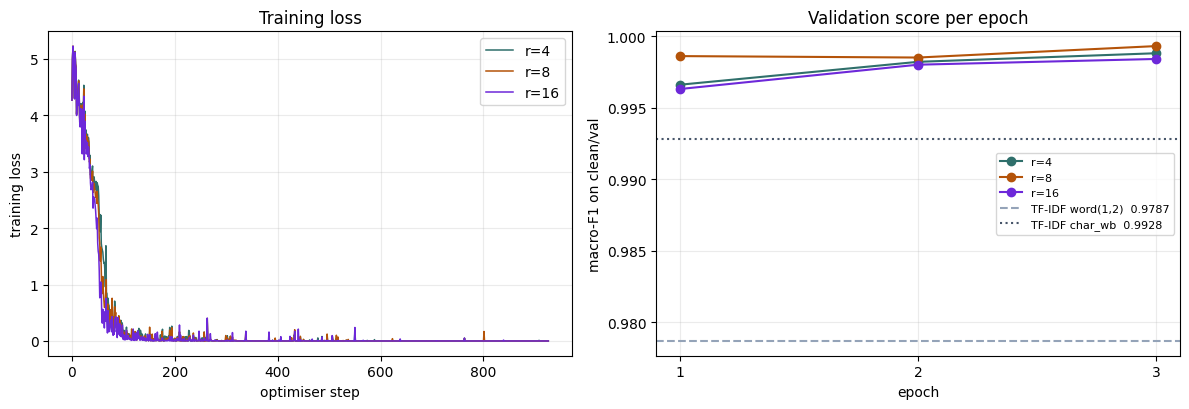

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
colours = {4: "#2f6f6b", 8: "#b45309", 16: "#6d28d9"}
def colour(r): return colours.get(r, "#334155")

for o in sweep:
    r = o["record"]["config"]["r"]
    axes[0].plot(o["step_losses"], color=colour(r), linewidth=1.1, label=f"r={r}")
    epochs = [h["epoch"] for h in o["history"]]
    axes[1].plot(epochs, [h["val_f1_macro"] for h in o["history"]],
                 marker="o", color=colour(r), label=f"r={r}")

axes[0].set_xlabel("optimiser step"); axes[0].set_ylabel("training loss")
axes[0].set_title("Training loss"); axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].axhline(BASELINE, color="#94a3b8", linestyle="--",
                label=f"TF-IDF word(1,2)  {BASELINE:.4f}")
axes[1].axhline(STRONGEST, color="#475569", linestyle=":",
                label=f"TF-IDF char_wb  {STRONGEST:.4f}")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("macro-F1 on clean/val")
axes[1].set_title("Validation score per epoch"); axes[1].set_xticks(epochs)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.25)

fig.tight_layout()
fig.savefig(OUT_FIGURES / "07_lora_r_sweep.png", dpi=150, bbox_inches="tight")
plt.show()


In [23]:
# Per-intent detail, the error file and the confusion table - for every run in the
# sweep, not only the best one. The predictions are already in memory, so all three
# tables per run cost a disk write; rebuilding any single one of them later costs
# the GPU hour that produced it.
#
# An earlier version wrote these for the highest-scoring run only, even though the
# other two runs' tables were sitting in memory at that moment. That made "which
# intents are hard" an argument about one rank when it could have been an argument
# about three.
for o in sweep:
    o_name = o["record"]["name"]
    E.per_class_frame(o["record"]["metrics"]).to_csv(
        OUT_METRICS / f"{o_name}_per_intent.csv", index=False)
    E.error_frame(clean_va, o["predictions"], confidence=o["confidence"]).to_csv(
        OUT_ERRORS / f"{o_name}_errors.csv", index=False)
    E.top_confusions(clean_va["intent"], o["predictions"], k=10, labels=INTENTS).to_csv(
        OUT_METRICS / f"{o_name}_confusions.csv", index=False)
print(f"per-intent, errors and confusions written for all {len(sweep)} run(s)")

# On screen, only the highest-scoring run: three 27-row tables is not something
# anybody reads in a notebook, and all three are on disk either way.
best = max(sweep, key=lambda o: o["record"]["metrics"]["f1_macro"])
name = best["record"]["name"]

per_class = E.per_class_frame(best["record"]["metrics"])
print(f"\nhardest intents for {name}:")
display(per_class.head(8))

errors = E.error_frame(clean_va, best["predictions"], confidence=best["confidence"])
confusions = E.top_confusions(clean_va["intent"], best["predictions"], k=10, labels=INTENTS)
print(f"\n{len(errors)} errors out of {len(clean_va)} rows. Top confusions:")
display(confusions)
print("\nThis is a highest-in-the-table row, not a winner. See section 4.")

per-intent, errors and confusions written for all 3 run(s)

hardest intents for run_04_lora_r8:


,intent,precision,recall,f1,support
0,track_order,0.975,1.000,0.9873,39
1,check_invoice,1.000,0.988,0.9939,83
2,change_shipping_address,1.000,1.000,1.0000,102
3,cancel_order,1.000,1.000,1.0000,30
4,check_cancellation_fee,1.000,1.000,1.0000,77
5,check_payment_methods,1.000,1.000,1.0000,74
6,check_refund_policy,1.000,1.000,1.0000,55
7,change_order,1.000,1.000,1.0000,78



1 errors out of 2120 rows. Top confusions:


,true,predicted,count,share_of_true
0,check_invoice,track_order,1,0.012



This is a highest-in-the-table row, not a winner. See section 4.


## 6 - Summary

In [24]:
lines = [
    f"GPU                {HARDWARE['gpu_name']}  ({HARDWARE['precision']}, "
    f"{HARDWARE['precision_reason']})",
    f"transformers       {VERSIONS['transformers']}",
    "",
    f"BASELINES, all on the same {len(val_score):,} clean/val rows and the same "
    "scoring function:",
    f"  majority class                    macro-F1 {FLOOR:.4f}",
    f"  Qwen3-1.7B zero-shot, untrained   macro-F1 {record_zero['metrics']['f1_macro']:.4f}", 
    f"  TF-IDF word(1,2)                  macro-F1 {BASELINE:.4f}",
    f"  TF-IDF char_wb(3,5)               macro-F1 {STRONGEST:.4f}",
    "",
    "FINE-TUNED, r sweep (raw data - no winner declared here):",
]
for o in sweep:
    c, m = o["record"]["config"], o["record"]["metrics"]
    lines.append(f"  r={c['r']:<3d} alpha={c['lora_alpha']:<3d} "
                 f"macro-F1 {m['f1_macro']:.4f}  "
                 f"{c['trainable_pct']}% of parameters trained  "
                 f"{o['record']['runtime_seconds']:.0f}s")
lines += [
    "",
    f"spread across {len(sweep)} r value(s)  {spread:.4f}",
    "  -> uninterpretable until the resolution floor is known (see 03b_resolution_floor.ipynb).",
]
print("\n".join(lines))

GPU                NVIDIA L4  (bf16, bf16 supported by this GPU - preferred, no loss scaling needed)
transformers       5.14.1

BASELINES, all on the same 2,120 clean/val rows and the same scoring function:
  majority class                    macro-F1 0.0041
  Qwen3-1.7B zero-shot, untrained   macro-F1 0.5269
  TF-IDF word(1,2)                  macro-F1 0.9787
  TF-IDF char_wb(3,5)               macro-F1 0.9928

FINE-TUNED, r sweep (raw data - no winner declared here):
  r=4   alpha=8   macro-F1 0.9988  0.0498% of parameters trained  222s
  r=8   alpha=16  macro-F1 0.9993  0.0964% of parameters trained  221s
  r=16  alpha=32  macro-F1 0.9984  0.1895% of parameters trained  222s

spread across 3 r value(s)  0.0009
  -> uninterpretable until the resolution floor is known (see 03b_resolution_floor.ipynb).


### What was deliberately not done here

- **`clean/test` was not opened.** Every number above is on `clean/val`. A number used to
  choose between configurations is no longer a neutral estimate of performance, which is
  exactly why a separate test set exists and is opened once, in `04_test.ipynb`.
- **No configuration was frozen.** That is step 16, and it waits for the resolution floor.
- **The naive split was not touched.** It enters in `04_test.ipynb`, with a frozen configuration.
- **No LoRA modules were added beyond `q_proj` and `v_proj`.** Widening the target modules is a
  separate experiment on the chosen `r`, not a mid-sweep fix.
- **Nothing about confidence.** Every number above answers "was the prediction right",
  never "how sure was it". The number beside each prediction is measured in
  `03c_confidence.ipynb`, off saved logits, on CPU.

### Checklist

Copy into the run log and tick while running:

- [ ] **before connecting: `git push`** - on Colab this notebook runs the pushed commit, not the editor's copy
- [ ] the commit printed by the bootstrap cell is the one you meant to run
- [ ] Drive mounted (`DRIVE_OK` is True) - if not, stop and fix it before the sweep
- [ ] blocking: transformers version checked and written down
- [ ] blocking: GPU name and bf16 support written down; precision chosen from the answer
- [ ] blocking: pad token set, model and tokenizer agree on its id
- [ ] the manifest assert passed in this notebook
- [ ] the frozen hyper-parameter cell was run before the first training run
- [ ] step 13: the debug run passed all seven checks
- [ ] step 13: save -> load -> predict returned identical predictions
- [ ] step 14: zero-shot on `clean/val` by label scoring
- [ ] step 14: the prompt text saved to `results/prompts/`
- [ ] step 15: three runs, r in {4, 8, 16}, everything else frozen
- [ ] run records written, including hardware, versions, seed, trainable parameters, runtime
- [ ] the three adapters are on Drive **and the files were verified to be there**
- [ ] `results/` from the runtime committed and pushed, or copied off - the clone is disposable
- [ ] the sweep table is filled in, with no winner declared
- [ ] the runtime was shut down explicitly
- [ ] commit, and an entry in the run log

**Next (`03b_resolution_floor.ipynb`):** one row of `clean/val` flipped at a time gives what a
single validation row is worth - the resolution floor. Only then is the configuration frozen, and only
then can these three rows be read.

In [25]:
import shutil
import subprocess

# Verify the adapters really are on Drive before the runtime is closed. "save_pretrained
# did not raise" is not the same claim as "the file is there": a Drive mount can drop
# mid-session and the writes go to a local path that disappears with the machine.
print("adapters:")
for record in RECORDS:
    if "adapter_dir" not in record:
        print(f"  [ -- ]  {record['name']:24s}   no adapter (nothing was trained)")
        continue
    adapter = Path(record["adapter_dir"])
    weights = adapter / "adapter_model.safetensors"
    size = weights.stat().st_size / 1e6 if weights.exists() else 0
    print(f"  [{'OK  ' if size else 'GONE'}]  {record['name']:24s} {size:7.1f} MB  {adapter}")

# results/ is written into the clone, which is disposable in exactly the same way as
# the runtime's own disk. An earlier session ended here with a printed list of thirteen
# files and an instruction to commit them; the runtime was closed instead, and eleven of
# the thirteen were gone. The instruction was not the weak part - the weak part was that
# the last step of an expensive run was something a person had to remember under time
# pressure.
#
# So it happens here, in the code that produced the files, into the same Drive the
# adapters already go to. Git stays the archive; this is the copy that does not
# depend on anybody doing anything. A few MB, about a second.
if DRIVE_OK:
    print("\nmirroring to Drive:")
    for folder in ("results",):
        source, target = REPO_ROOT / folder, DRIVE_ROOT / folder
        if not source.exists():
            continue
        shutil.copytree(source, target, dirs_exist_ok=True)
        n = sum(1 for p in target.rglob("*") if p.is_file())
        print(f"  [OK  ]  {folder:8s} -> {target}  ({n} files)")
    print("\n^ that copy survives this runtime. Check the count looks right before")
    print("  running the next cell - the next cell is what destroys the machine.")
elif IN_COLAB:
    print("\n!! Drive is not mounted, so the adapters above AND everything in results/")
    print("   live on this runtime's disk and die with it. Copy both somewhere")
    print(f"   permanent BEFORE disconnecting:  {RUNS_DIR}  and  {REPO_ROOT / 'results'}")
else:
    print("\nlocal run - results/ is already in the working tree, nothing to mirror.")

# The Drive copy is a backup, not the archive: the numbers belong in git, and a file
# that is only on Drive is a file that is not in the repository the report is graded
# from. So the pending list is still printed - it is a reminder now rather than the
# last chance it used to be.
if IN_COLAB:
    changed = subprocess.run(["git", "status", "--porcelain", "results"],
                             cwd=REPO_ROOT, capture_output=True, text=True).stdout.strip()
    print("\nresults/ produced on this runtime (not yet in git):")
    print(changed if changed else "  (none - which on a real run is itself suspicious)")
    print("\n  cd /content/support-triage")
    print('  git add results && git commit -m "r sweep outputs" && git push')

adapters:
  [OK  ]  run_00_debug_0p6b            4.7 MB  /content/drive/MyDrive/support-triage/runs/run_00_debug_0p6b
  [ -- ]  run_01_zeroshot_1p7b       no adapter (nothing was trained)
  [OK  ]  run_03_lora_r4               3.4 MB  /content/drive/MyDrive/support-triage/runs/run_03_lora_r4
  [OK  ]  run_04_lora_r8               6.7 MB  /content/drive/MyDrive/support-triage/runs/run_04_lora_r8
  [OK  ]  run_05_lora_r16             13.1 MB  /content/drive/MyDrive/support-triage/runs/run_05_lora_r16

mirroring to Drive:
  [OK  ]  results  -> /content/drive/MyDrive/support-triage/results  (52 files)

^ that copy survives this runtime. Check the count looks right before
  running the next cell - the next cell is what destroys the machine.

results/ produced on this runtime (not yet in git):
M results/figures/07_lora_r_sweep.png
 M results/metrics/gpu_runs_summary.csv
 M results/metrics/lora_r_sweep.csv
 M results/prompts/zero_shot.txt
?? results/errors/run_03_lora_r4_errors.csv
?? results

In [26]:
# Shut the runtime down explicitly. An idle GPU runtime burns compute units and
# produces nothing, and "I will close it in a minute" is how a day's reserve goes.
#
# Do not run this until the cell above shows the adapters and the results/ files
# where you want them: unassigning is what destroys the machine holding them.
print("Everything is written. Closing the runtime.")

if IN_COLAB:
    try:
        from google.colab import runtime
        runtime.unassign()
    except Exception as exc:
        print(f"\ncould not release the runtime from here - {type(exc).__name__}: {exc}")
        print("Not every google.colab call is bridged into VS Code. Disconnect by hand:")
        print("  VS Code    kernel picker > Disconnect")
        print("  or         https://colab.research.google.com > Runtime > Manage sessions")

Everything is written. Closing the runtime.
